In [2]:
import openslide
import matplotlib.pyplot as plt
import json
from shapely.geometry import shape
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

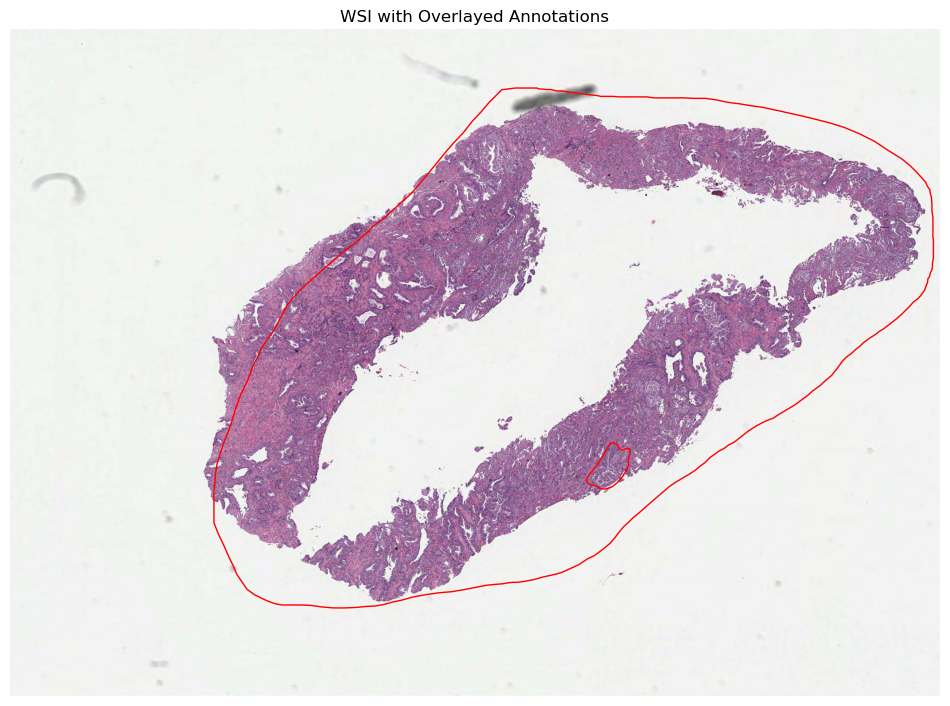

In [3]:
# File paths
PT_SVS = '/Users/user/Documents/projects/GlandSeg/tmp/TCGA-HC-7209-01Z-00-DX1.ccf1d3c8-0351-4b7e-8539-0817ce3b8364.svs'
PT_ANNOTATION = '/Users/user/Documents/projects/GlandSeg/tmp/TCGA-HC-7209-01Z-00-DX1.ccf1d3c8-0351-4b7e-8539-0817ce3b8364.geojson'

# Load the WSI
slide = openslide.OpenSlide(PT_SVS)

# Choose a display level (0 = highest resolution, higher numbers = lower resolutions)
level = 2
slide_rgb = slide.read_region((0, 0), level, slide.level_dimensions[level]).convert("RGB")

# Load geojson annotations
with open(PT_ANNOTATION, 'r') as f:
    geojson_data = json.load(f)

# Plot slide
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(slide_rgb)

# Scaling factor from level 0 to chosen level
scale_x = slide.level_dimensions[0][0] / slide.level_dimensions[level][0]
scale_y = slide.level_dimensions[0][1] / slide.level_dimensions[level][1]

# Draw polygons
patches = []
for feature in geojson_data['features']:
    coords = feature['geometry']['coordinates']
    
    # Handle MultiPolygon or Polygon
    if feature['geometry']['type'] == 'Polygon':
        polygons = [coords]
    elif feature['geometry']['type'] == 'MultiPolygon':
        polygons = coords
    else:
        continue  # skip other geometry types

    for poly in polygons:
        exterior = poly[0]  # only exterior ring
        scaled_coords = [(x / scale_x, y / scale_y) for x, y in exterior]
        patches.append(Polygon(scaled_coords, closed=True))

# Overlay polygons
p = PatchCollection(patches, facecolor='none', edgecolor='red', linewidths=1)
ax.add_collection(p)

ax.set_title("WSI with Overlayed Annotations")
ax.axis('off')
plt.show()